## Stock Price Forecasting with ARIMA

This project forecasts the future closing price of a stock (Apple, AAPL) using time series analysis. I check if the series is stationary, build an ARIMA model, forecast a test period, and measure how good the forecast is compared with a simple baseline. The objective is in order to forecast the closing price for the next days and understand how accurate (and how reliable) such a forecast can be.

## Approach
1. Download the data and plot the closing price
2. Explore the trend, rolling mean, and daily returns
3. Test if the series is stationary (ADF test) and make it stationary by differencing
4. Choose the ARIMA orders (p, d, q) with the ACF/PACF plots and by comparing the AIC score
5. Split the data in time order (train on the past, test on the last part), never randomly
6. Fit the ARIMA model and forecast the test period
7. Evaluate with RMSE, MAE, and MAPE, and compare with a naive baseline ("tomorrow = today")
8. Prepare for Streamlit

In [10]:
# Load the data
!pip install yfinance -q

import yfinance as yf
import pandas as pd

df = yf.download("AAPL", start="2018-01-01", end="2026-08-30", auto_adjust=True, progress=False)

In [11]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.232368,40.241713,39.531700,39.741903,102223600
2018-01-03,40.225376,40.767228,40.162319,40.295444,118071600
2018-01-04,40.412228,40.514993,40.190350,40.297784,89738400
2018-01-05,40.872314,40.958729,40.416881,40.507968,94640000
2018-01-08,40.720516,41.014796,40.622419,40.720516,82271200


In [12]:
df.columns = df.columns.droplevel(1)      # yfinance'in çift seviyeli sütun başlığını düzelt

In [13]:
df.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-08-24,310.339996,313.359985,309.970001,311.470001,34673600
2026-08-25,309.899994,313.589996,308.209991,310.790009,25869800
2026-08-26,313.450012,315.429993,308.799988,310.299988,34024500
2026-08-27,314.579987,315.399994,309.399994,310.549988,32419200
2026-08-28,319.700012,322.369995,315.450012,316.850006,38649400


In [14]:
df.shape

(2176, 5)

<Axes: title={'center': 'AAPL Closing Price'}, xlabel='Date'>

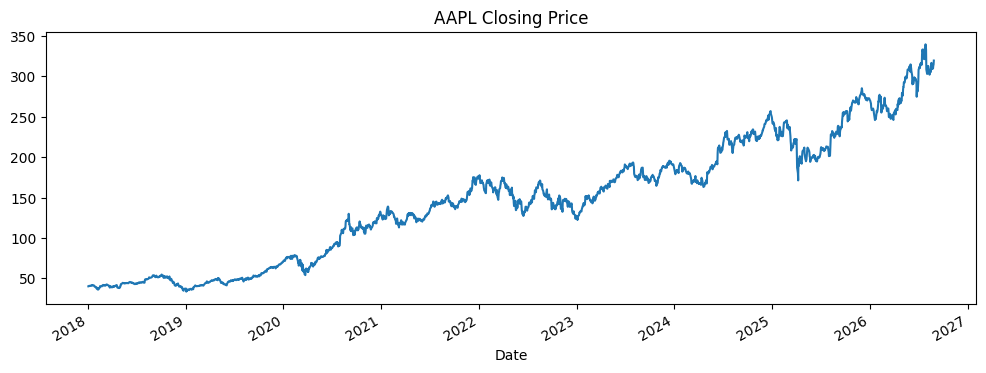

In [15]:
df["Close"].plot(figsize=(12, 4), title="AAPL Closing Price")

Text(0.5, 1.0, 'Price and Moving Averages')

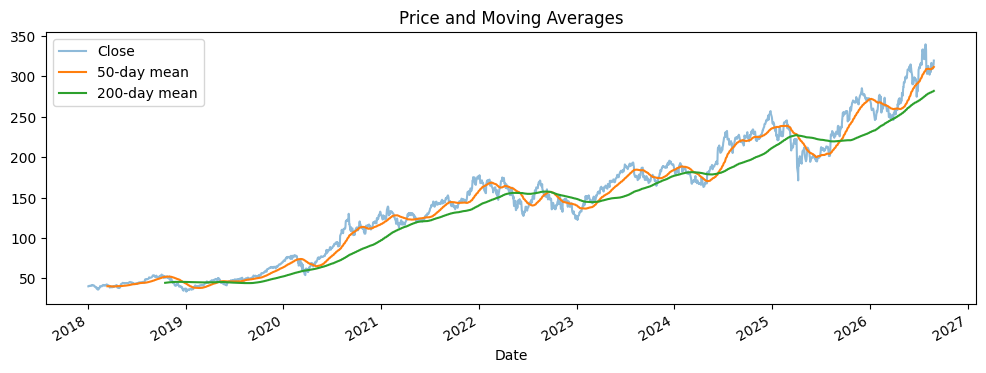

In [17]:
# EDA
import matplotlib.pyplot as plt
close = df["Close"]

close.plot(figsize=(12, 4), label="Close", alpha=0.5)
close.rolling(50).mean().plot(label="50-day mean")
close.rolling(200).mean().plot(label="200-day mean")
plt.legend(); plt.title("Price and Moving Averages")

,Close
count,2175.0000
mean,0.0011
std,0.0192
min,-0.1286
25%,-0.0079
50%,0.0012
75%,0.0109
max,0.1533


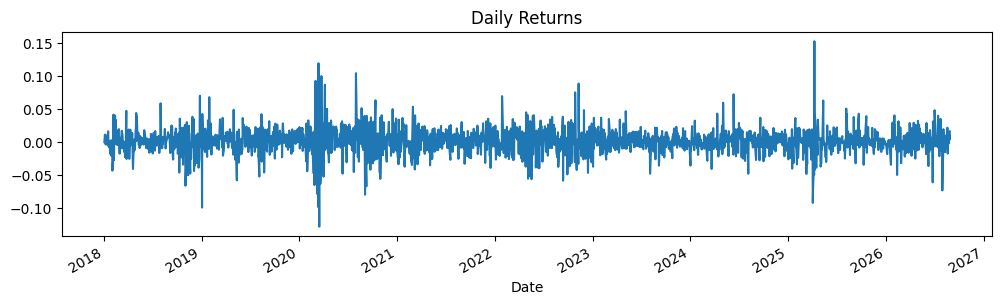

In [18]:
returns = close.pct_change().dropna()
returns.plot(figsize=(12, 3), title="Daily Returns")
returns.describe().round(4)

In [19]:
# Test if the series is stationary
from statsmodels.tsa.stattools import adfuller

adf = lambda s: pd.Series(adfuller(s.dropna())[:2], index=["ADF statistic", "p-value"]).round(4)

pd.DataFrame({"Close": adf(close), "Close (1st difference)": adf(close.diff())})

/tmp/ipykernel_1363/343757310.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = lambda s: pd.Series(adfuller(s.dropna())[:2], index=["ADF statistic", "p-value"]).round(4)
/tmp/ipykernel_1363/343757310.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = lambda s: pd.Series(adfuller(s.dropna())[:2], index=["ADF statistic", "p-value"]).round(4)


,Close,Close (1st difference)
ADF statistic,0.1623,-22.4795
p-value,0.9701,0.0000


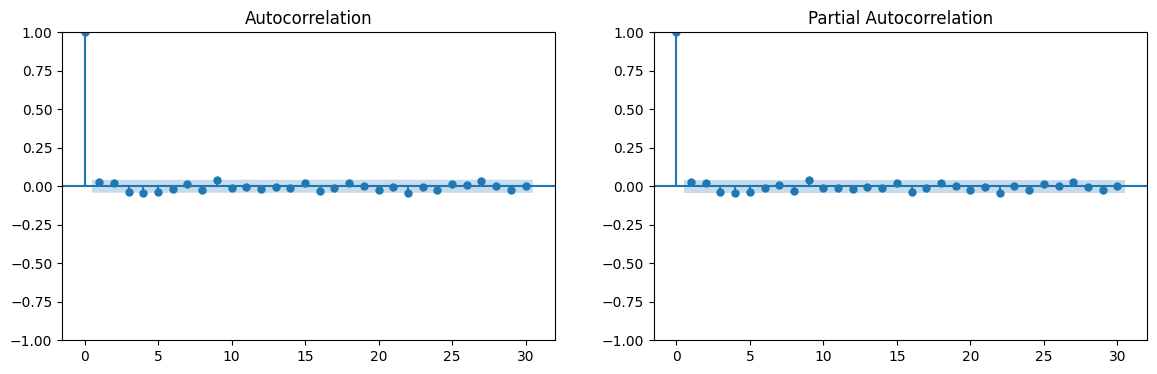

In [20]:
# Choose the ARIMA order
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(close.diff().dropna(), lags=30, ax=ax[0])
plot_pacf(close.diff().dropna(), lags=30, ax=ax[1], method="ywm")
plt.show()

In [21]:
from statsmodels.tsa.arima.model import ARIMA

pd.DataFrame(
    {f"ARIMA({p},1,{q})": {"AIC": ARIMA(close, order=(p, 1, q)).fit().aic}
     for p in range(3) for q in range(3)}
).T.round(1).sort_values("AIC")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, fr

,AIC
"ARIMA(2,1,2)",10743.8
"ARIMA(0,1,0)",10746.4
"ARIMA(1,1,0)",10746.8
"ARIMA(0,1,1)",10746.9
"ARIMA(0,1,2)",10747.4
"ARIMA(2,1,0)",10747.7
"ARIMA(1,1,2)",10748.5
"ARIMA(1,1,1)",10748.6
"ARIMA(2,1,1)",10749.1


In [23]:
# Split train and test
close_r = close.reset_index(drop=True)
train, test = close_r[:-100], close_r[-100:]
fits = {f"ARIMA{o}": ARIMA(train, order=o).fit() for o in [(0, 1, 0), (2, 1, 2)]}

preds = pd.DataFrame({
    **{f"{n} 1-day": f.apply(close_r).get_prediction(start=len(train)).predicted_mean for n, f in fits.items()},
    **{f"{n} 100-day": f.forecast(100) for n, f in fits.items()},
    "Naive (yesterday)": close_r.shift(1)[-100:],
})

err = preds.sub(test, axis=0)
pd.DataFrame({"RMSE": (err**2).mean()**0.5, "MAE": err.abs().mean(), "MAPE %": err.abs().div(test, axis=0).mean() * 100}).round(2)

,RMSE,MAE,MAPE %
"ARIMA(0, 1, 0) 1-day",5.47,3.94,1.32
"ARIMA(2, 1, 2) 1-day",5.46,3.95,1.32
"ARIMA(0, 1, 0) 100-day",50.79,46.65,15.17
"ARIMA(2, 1, 2) 100-day",50.83,46.70,15.19
Naive (yesterday),5.47,3.94,1.32


In [24]:
drift = ARIMA(train, order=(0, 1, 0), trend="t").fit().forecast(100)
(drift - test).abs().mean(), ((drift - test) ** 2).mean() ** 0.5

(np.float64(41.47549201017339), np.float64(45.18453433211949))

<Axes: title={'center': 'Forecast vs Actual (last 100 days)'}>

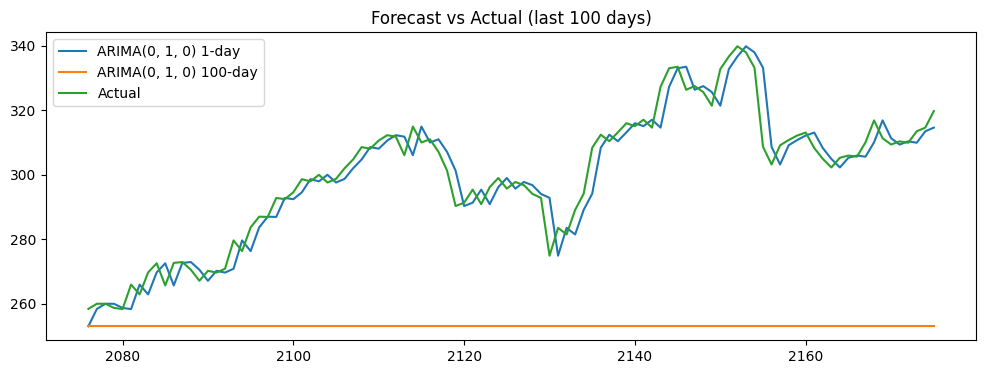

In [25]:
preds[["ARIMA(0, 1, 0) 1-day", "ARIMA(0, 1, 0) 100-day"]].assign(Actual=test).plot(figsize=(12, 4), title="Forecast vs Actual (last 100 days)")

Text(0.5, 1.0, '100-day Forecast vs Actual')

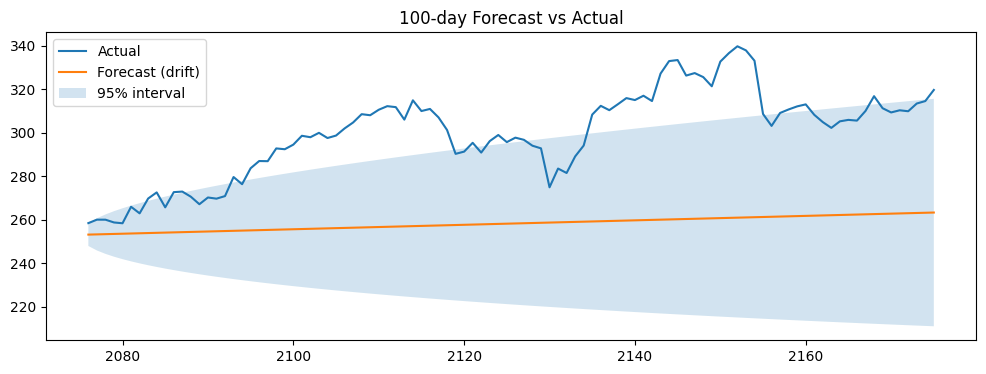

In [26]:
fc = ARIMA(train, order=(0, 1, 0), trend="t").fit().get_forecast(100)
ci = fc.conf_int()

ax = test.plot(figsize=(12, 4), label="Actual")
fc.predicted_mean.plot(ax=ax, label="Forecast (drift)")
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, label="95% interval")
ax.legend(); ax.set_title("100-day Forecast vs Actual")